# Notebook 1: Repository Evaluation

One repository; run per repository by `analysis repo-report`. Same sections as Notebook 2.

In [1]:
# repo_name is injected by papermill when running via `analysis repo-report`.
if 'repo_name' not in dir():
    repo_name = None

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.plots import (
    before_after_slope, cost_vs_improvement_scatter, outcome_classification_bar,
    outcome_funnel, smell_type_breakdown, timing_stacked_bar,
)

sns.set_theme(style='whitegrid')

DATA_DIR = Path(os.environ.get('ANALYSIS_DATA_DIR', '../../data'))


def load(name, required=False):
    path = DATA_DIR / name
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Missing required analysis CSV: {path}')
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)


attempts = load('evaluation_attempts.csv', required=True)
candidates = load('evaluation_candidates.csv', required=True)
gen_tests = load('generated_tests.csv')
mutation_ops = load('mutation_operators.csv')

failures = load('failures/failure_cases.csv')

In [3]:
if repo_name and repo_name in attempts['repo_name'].values:
    REPO_NAME = repo_name
else:
    if repo_name:
        print(f'[warn] repo_name={repo_name!r} not found; using the first repository.')
    REPO_NAME = attempts['repo_name'].iloc[0]
REPO_OWNER = attempts.loc[attempts['repo_name'] == REPO_NAME, 'repo_owner'].iloc[0]
COMMIT_HASH = None   # None = any commit

mask = (attempts['repo_owner'] == REPO_OWNER) & (attempts['repo_name'] == REPO_NAME)
if COMMIT_HASH:
    mask &= attempts['commit_hash'] == COMMIT_HASH
ALL = attempts[mask]
# Infrastructure failures are missing data, not model or tool failures.
from analysis.normalize import final_chain_outcomes

# One row per chain at its final outcome. Repair steps are children of one attempt,
# so outcomes and metric movement count each chain once; time is summed over the
# steps (chain_*_duration_seconds) and effective_tokens is already the chain total.
A = final_chain_outcomes(ALL)
C = candidates[candidates['repository_key'].isin(ALL['repository_key'].unique())]
T = gen_tests[gen_tests['attempt_id'].isin(ALL['attempt_id'])] if not gen_tests.empty else gen_tests
M = mutation_ops[mutation_ops['repository_key'].isin(ALL['repository_key'])] if not mutation_ops.empty else mutation_ops

print(f"Repository: {REPO_OWNER}/{REPO_NAME} @ {ALL['commit_hash'].iloc[0][:12]}")
print(f"Candidate methods: {A['candidate_key'].nunique()}; chains: {len(C)}; "
      f'attempts: {len(A)} (+{len(ALL) - len(A)} infrastructure failures excluded)')

if len(ALL) > len(A):
    display(ALL[ALL['infrastructure_failure'].astype(bool)]
            .groupby(['lane', 'producer', 'infrastructure_failure_reason']).size().rename('attempts'))

Repository: cysharp/zstring @ e2b86f7ad433
Candidate methods: 1; chains: 39; attempts: 35 (+12 infrastructure failures excluded)


lane  producer                                     infrastructure_failure_reason
llm   Kimi-K3-thinking-high                        provider_http_error              2
                                                   repair_input_missing             4
      us.anthropic.claude-haiku-4-5-20251001-v1:0  provider_auth                    2
                                                   repair_input_missing             4
Name: attempts, dtype: int64

## Chains

One row per candidate method, producer and budget arm. `first_attempt_success` is pass@1; `any_validated_success` is the result after repair.

In [4]:
chain_cols = ['lane', 'producer', 'budget_mode', 'first_attempt_success', 'any_validated_success',
              'validated_evidence_positive_count', 'validated_low_impact_count',
              'best_coverage_delta', 'best_mutation_delta', 'attempt_count', 'infrastructure_failure_count']
C[chain_cols].sort_values(['lane', 'producer', 'budget_mode'])

,lane,producer,budget_mode,first_attempt_success,any_validated_success,validated_evidence_positive_count,validated_low_impact_count,best_coverage_delta,best_mutation_delta,attempt_count,infrastructure_failure_count
50,agentic,aider-anthropic,PassAt1,True,True,0,1,0.00,0.000000,1,0
53,agentic,aider-custom-glm,PassAt1,True,True,1,0,0.48,0.086747,1,0
59,agentic,aider-custom-gpt,PassAt1,True,True,0,1,0.00,0.009639,1,0
56,agentic,aider-custom-kimi,PassAt1,True,True,1,0,0.48,0.144578,1,0
43,agentic,aider-gemini,PassAt1,True,True,1,0,0.48,0.134940,1,0
45,agentic,aider-openai,PassAt1,True,True,1,0,0.48,0.144578,1,0
82,agentic,claude,PassAt1,True,True,1,0,0.48,0.134940,1,0
88,agentic,codex,PassAt1,True,True,1,0,0.42,0.134940,1,0
94,agentic,copilot-anthropic,PassAt1,True,True,1,0,0.48,0.453012,1,0
102,agentic,copilot-custom-glm,PassAt1,True,True,1,0,0.48,0.192771,1,0


## Baseline and source methods

In [5]:
method_cols = [c for c in [
    'repo_name', 'source_method_name', 'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_sloc', 'source_method_baseline_coverage', 'coverage_before', 'mutation_score_before',
] if c in A.columns]
# Method properties: one row per candidate method.
display(A.groupby('candidate_key')[method_cols].first().reset_index(drop=True).round(2))

,repo_name,source_method_name,source_method_cc,source_method_mi,source_method_coupling,source_method_sloc,source_method_baseline_coverage,coverage_before,mutation_score_before
0,zstring,Concat,10,52,3,61,0.52,0.52,10.24


## Outcomes

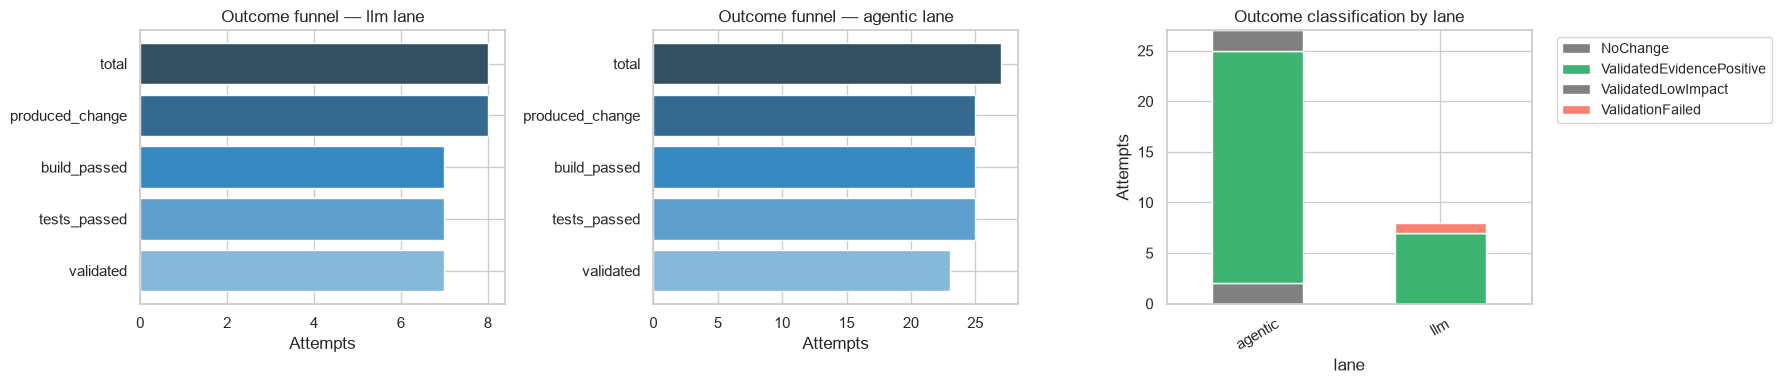

chains           %      
lane                      agentic llm agentic   llm
outcome_classification                             
NoChange                        2   0     7.4   0.0
ValidatedEvidencePositive      23   7    85.2  87.5
ValidatedLowImpact              2   0     7.4   0.0
ValidationFailed                0   1     0.0  12.5

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
outcome_funnel(A, lane='llm', ax=axes[0])
outcome_funnel(A, lane='agentic', ax=axes[1])
outcome_classification_bar(A, group_col='lane', ax=axes[2])
plt.tight_layout()
plt.show()

counts = A.groupby(['outcome_classification', 'lane']).size().unstack(fill_value=0)
display(pd.concat({'chains': counts, '%': counts.div(counts.sum()).mul(100).round(1)}, axis=1))

## Metric movement

Coverage is a 0-1 fraction; mutation score is 0-100.

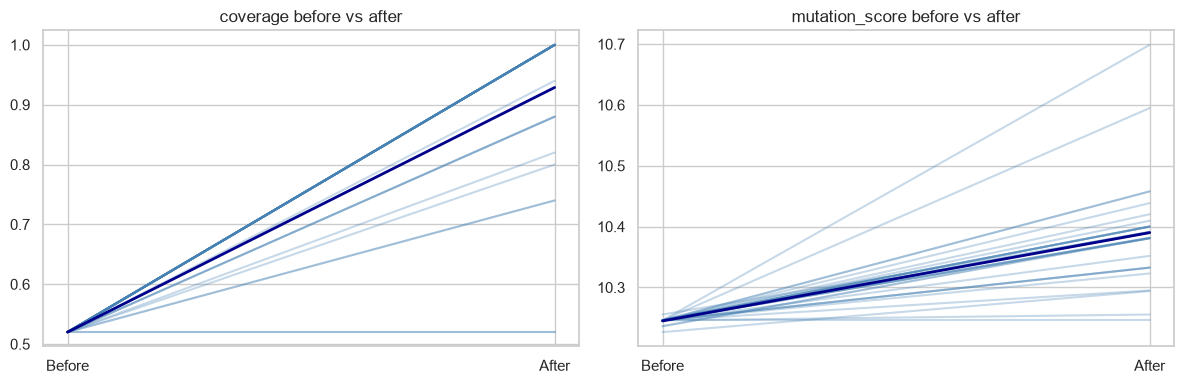

lines_closed               mutants_newly_killed              
               count    sum median                count    sum median
lane                                                                 
agentic           25  604.0   28.0                   25  118.0    5.0
llm                7  152.0   20.0                    7   34.0    5.0

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_after_slope(A, 'coverage_before', 'coverage_after', ax=axes[0])
before_after_slope(A, 'mutation_score_before', 'mutation_score_after', ax=axes[1])
plt.tight_layout()
plt.show()

# Set differences against the target member: baseline gap lines closed, baseline survivors killed.
diff_cols = [c for c in ['lines_closed', 'mutants_newly_killed'] if c in A.columns]
if diff_cols:
    display(A.groupby('lane')[diff_cols].agg(['count', 'sum', 'median']))

## Generated tests

,tests_per_attempt,max_per_attempt,tests
lane,,,
agentic,6.09,34,140
llm,1.00,1,8


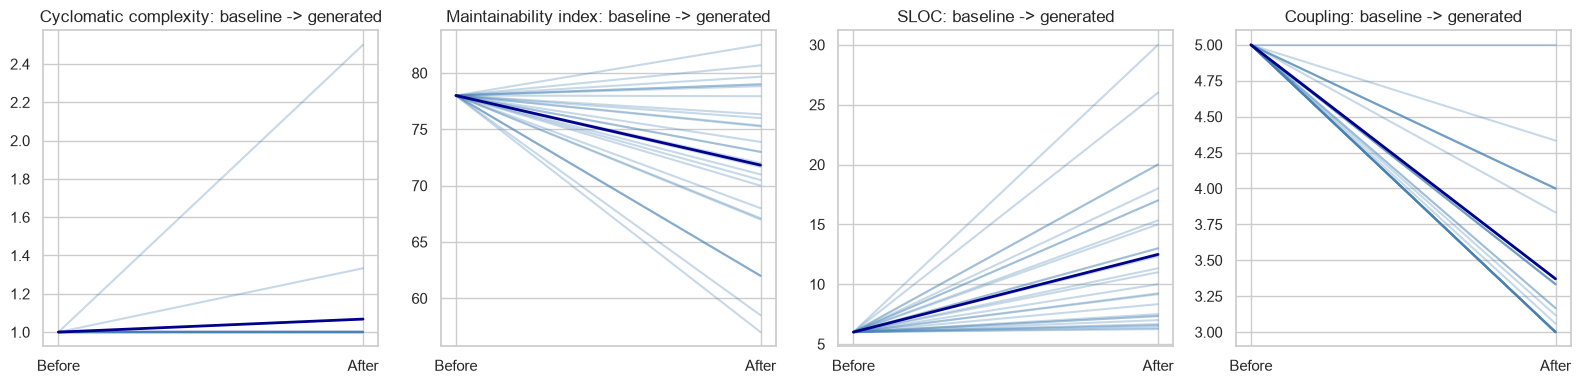

,baseline_test_cc,generated_test_cc,baseline_test_mi,generated_test_mi,baseline_test_sloc,generated_test_sloc,baseline_test_coupling,generated_test_coupling
lane,,,,,,,,
agentic,1.0,1.0,78.0,74.57,6.0,9.2,5.0,3.17
llm,1.0,1.0,78.0,71.00,6.0,15.0,5.0,3.00


In [8]:
if not T.empty:
    per_attempt = T.groupby(['lane', 'attempt_id']).size()
    display(per_attempt.groupby('lane').agg(['mean', 'max', 'sum'])
            .rename(columns={'mean': 'tests_per_attempt', 'max': 'max_per_attempt', 'sum': 'tests'})
            .round(2))

metric_pairs = [
    ('baseline_test_cc', 'generated_test_cc', 'Cyclomatic complexity'),
    ('baseline_test_mi', 'generated_test_mi', 'Maintainability index'),
    ('baseline_test_sloc', 'generated_test_sloc', 'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
metric_pairs = [p for p in metric_pairs if p[0] in A.columns and p[1] in A.columns]
fig, axes = plt.subplots(1, len(metric_pairs), figsize=(4 * len(metric_pairs), 4), squeeze=False)
for ax, (before_col, after_col, label) in zip(axes[0], metric_pairs):
    before_after_slope(A, before_col, after_col, ax=ax)
    ax.set_title(f'{label}: baseline -> generated')
plt.tight_layout()
plt.show()
display(A.groupby('lane')[[c for pair in metric_pairs for c in pair[:2]]].median().round(2))

## Test smells

,n,mean_smells,median_smells
tests,,,
baseline (one example test per method),1,1.00,1.0
generated (one row per generated test),148,1.62,2.0


,count,mean,median
lane,,,
agentic,23,1.72,1.83
llm,8,2.00,2.00


,count,mean,median
lane,,,
agentic,140,1.6,2.0
llm,8,2.0,2.0


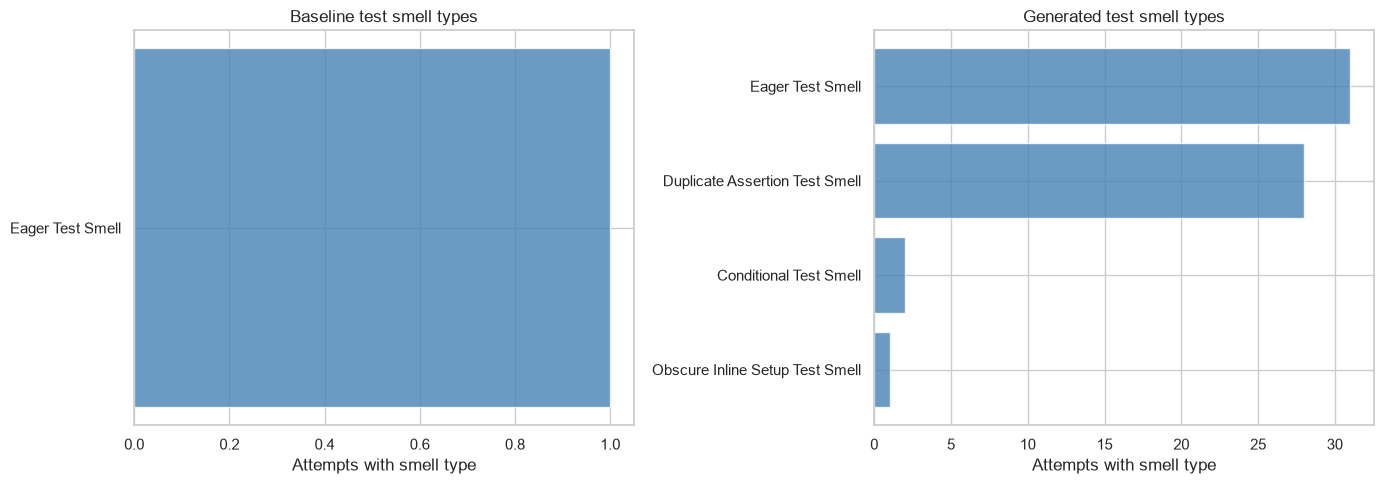

In [9]:
# The baseline test belongs to the candidate method, so it is counted once per method.
baseline = A.drop_duplicates('candidate_key')
produced = A[A['generated_test_count'].fillna(0) > 0].assign(
    smells_per_test=lambda d: d['generated_test_smell_count'] / d['generated_test_count'])
# Per test, not per attempt: an agentic attempt can write several tests, so its
# attempt-level smell count is a batch total and is not comparable to one baseline test.
gt = (gen_tests[(gen_tests['repo_owner'] == REPO_OWNER) & (gen_tests['repo_name'] == REPO_NAME)]
      if {'repo_owner', 'repo_name'} <= set(gen_tests.columns) else gen_tests)
rows = [{'tests': 'baseline (one example test per method)',
         'n': int(baseline['baseline_test_smell_count'].notna().sum()),
         'mean_smells': baseline['baseline_test_smell_count'].mean(),
         'median_smells': baseline['baseline_test_smell_count'].median()}]
if len(gt) and 'generated_test_smell_count' in gt:
    per_test = gt['generated_test_smell_count']
    rows.append({'tests': 'generated (one row per generated test)', 'n': int(per_test.notna().sum()),
                 'mean_smells': per_test.mean(), 'median_smells': per_test.median()})
display(pd.DataFrame(rows).set_index('tests').round(2))

# Attempt-derived view, kept as a cross-check of the per-test figure above.
display(produced.groupby('lane')['smells_per_test'].agg(['count', 'mean', 'median']).round(2))
if len(gt) and {'lane', 'generated_test_smell_count'} <= set(gt.columns):
    display(gt.groupby('lane')['generated_test_smell_count']
            .agg(['count', 'mean', 'median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smell_type_breakdown(baseline, 'baseline_test_smell_types', ax=axes[0])
axes[0].set_title('Baseline test smell types')
smell_type_breakdown(produced, 'generated_test_smell_types', ax=axes[1])
axes[1].set_title('Generated test smell types')
plt.tight_layout()
plt.show()

## Assertions

In [10]:
validated = A[A['validated_success'] == True]
measured = validated[validated['recognized_assertion_count'].notna()]
print(f'Validated successes: {len(validated)}; assertion-measured: {len(measured)}; '
      f'zero recognized assertions: {int((measured["recognized_assertion_count"] == 0).sum())}')
unmeasured = validated[validated['recognized_assertion_count'].isna()]
if len(unmeasured):
    display(unmeasured.groupby(['lane', 'assertion_measurement_status', 'assertion_measurement_reason'],
                               dropna=False).size().rename('unmeasured validated successes'))
display(A.groupby('lane')['recognized_assertion_count'].agg(['count', 'median', 'min', 'max']))

Validated successes: 32; assertion-measured: 30; zero recognized assertions: 0


lane     assertion_measurement_status  assertion_measurement_reason 
agentic  Unavailable                   GeneratedTestMemberUnresolved    2
Name: unmeasured validated successes, dtype: int64

,count,median,min,max
lane,,,,
agentic,23,17.0,3.0,60.0
llm,7,3.0,2.0,7.0


## Baseline mutation profile

In [11]:
profiled = set(M['repository_key']) if not M.empty else set()
missing_profile = sorted(set(A['repository_key']) - profiled)
if missing_profile:
    print(f'No solution-scope baseline mutation report: {missing_profile}')
if not M.empty:
    m = M.assign(killable=M[['Killed', 'Survived']].fillna(0).sum(axis=1))
    display(m[m['killable'] >= 5].sort_values('survival_rate', ascending=False)
            [['repository_key', 'mutation_testing_report_id', 'mutator_name', 'Killed', 'Survived', 'survival_rate']].head(12))
    by_repo = m.groupby(['repository_key', 'mutation_testing_report_id'])[['Killed', 'Survived']].sum()
    display(by_repo.assign(survival_rate=by_repo['Survived'] / by_repo.sum(axis=1)).round(3))

,repository_key,mutation_testing_report_id,mutator_name,Killed,Survived,survival_rate
4,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Array initializer mutation,0,9,1.000000
23,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,MultiplyAssignmentExpression to DivideAssignme...,0,5,1.000000
36,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,String mutation,10,55,0.846154
9,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Conditional (false) mutation,2,9,0.818182
22,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,LogicalNotExpression to un-LogicalNotExpressio...,12,24,0.666667
8,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Boolean mutation,20,18,0.473684
10,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Conditional (true) mutation,6,5,0.454545
7,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Block removal mutation,35,16,0.313725
12,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Equality mutation,347,104,0.230599
3,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Arithmetic mutation,138,41,0.229050


,,Killed,Survived,survival_rate
repository_key,mutation_testing_report_id,,,
cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36f5105aa912,1,1124,342,0.233


## Agentic change footprint

In [12]:
agentic = A[A['lane'] == 'agentic']
footprint_cols = [c for c in ['changed_files_count', 'test_files_changed', 'production_files_changed',
                              'project_files_changed', 'deleted_files_count'] if c in agentic.columns]
display(agentic[footprint_cols].describe().T.round(2))
if 'production_files_changed' in agentic.columns:
    rate = agentic.groupby('tool_id')['production_files_changed'].apply(lambda s: (s.fillna(0) > 0).mean())
    print(f'Tools that changed production files: {int((rate > 0).sum())}/{len(rate)}')
    if (rate > 0).any():
        display(rate[rate > 0].round(3).rename('production_change_rate'))
display(agentic.groupby('validated_success')['changed_files_count'].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
changed_files_count,27.0,1.33,0.88,0.0,1.0,1.0,1.0,3.0
test_files_changed,27.0,0.89,0.32,0.0,1.0,1.0,1.0,1.0
production_files_changed,27.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
project_files_changed,27.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
deleted_files_count,27.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


Tools that changed production files: 0/27


,count,mean,std,min,25%,50%,75%,max
validated_success,,,,,,,,
False,2.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
True,25.0,1.44,0.82,1.0,1.0,1.0,1.0,3.0


## Cost and runtime

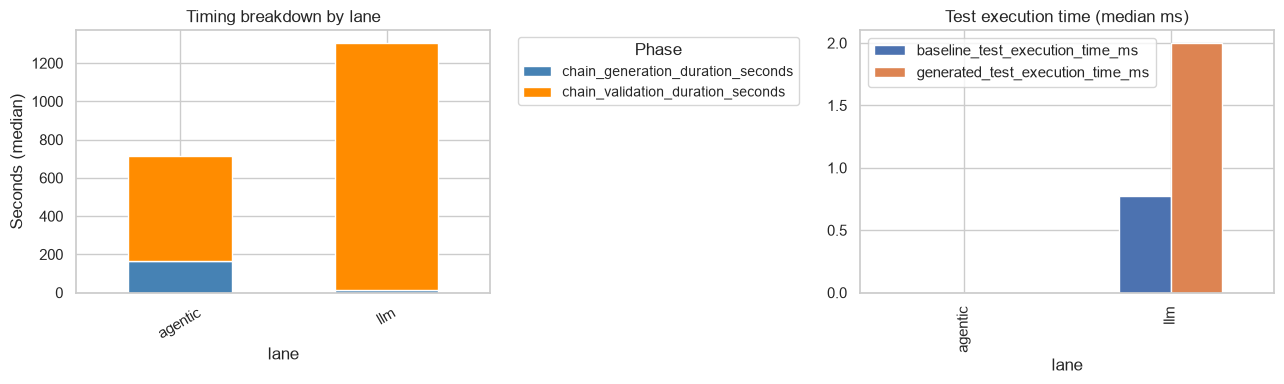

,count,median,sum
lane,,,
agentic,27,703.8,19497.1
llm,8,1308.1,9705.3


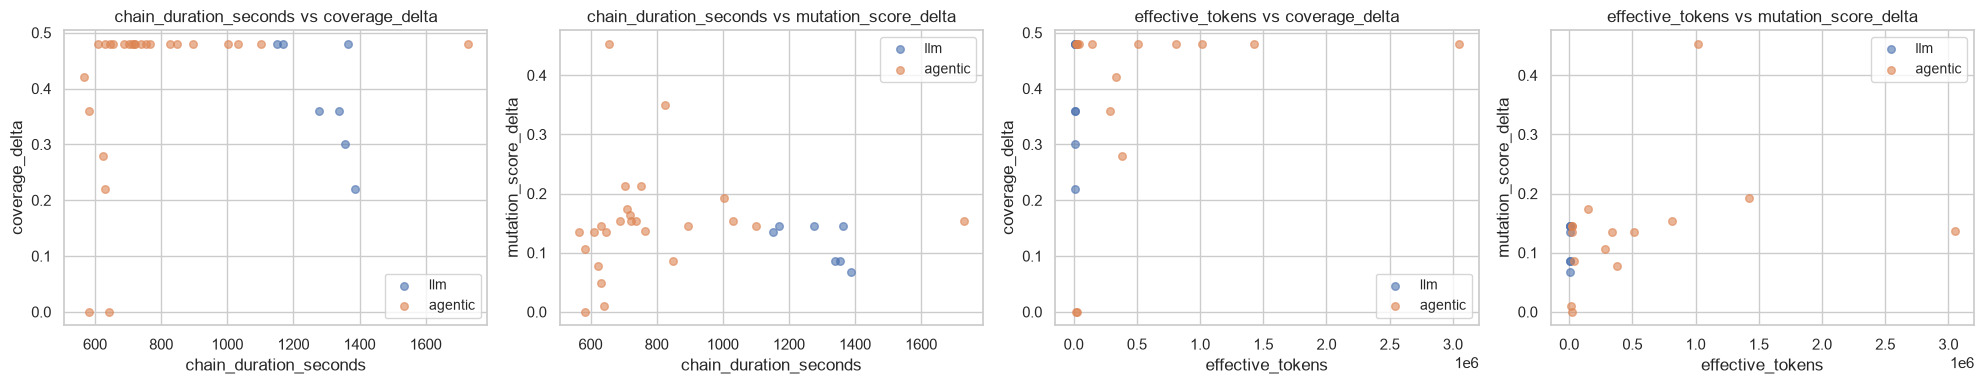

count        sum    median
lane    budget_mode                                 
agentic PassAt1              15  8120398.0  286683.0
llm     PassAt1               4    31036.0    7759.5
        PassAt1RepairAt5      4    31380.0    7834.0

usage_status,complete-estimated,complete-reported,missing,partial
lane,,,,
agentic,0,15,12,0
llm,8,0,8,4


No recorded usage: mini-swe-agent-anthropic, mini-swe-agent-custom-glm, mini-swe-agent-custom-gpt, mini-swe-agent-custom-kimi, mini-swe-agent-gemini, mini-swe-agent-openai, openhands-anthropic, openhands-custom-glm, openhands-custom-gpt, openhands-custom-kimi, openhands-gemini, openhands-openai


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(A, group_col='lane', gen_col='chain_generation_duration_seconds',
                   val_col='chain_validation_duration_seconds', ax=axes[0])
exec_cols = ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
A.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1], title='Test execution time (median ms)')
plt.tight_layout()
plt.show()
# Chain time: all repair steps together.
display(A.groupby('lane')['chain_duration_seconds'].agg(['count', 'median', 'sum']).round(1))

pairs = [(x, y) for x in ('chain_duration_seconds', 'effective_tokens')
         for y in ('coverage_delta', 'mutation_score_delta')]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (x, y) in zip(axes, pairs):
    cost_vs_improvement_scatter(A, x, y, 'lane', ax=ax)
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

# Chain cost: LLM terminal cumulative tokens, agentic run total. Chains without usage are left out.
display(C[C['effective_tokens'].notna()].groupby(['lane', 'budget_mode'])['effective_tokens']
        .agg(['count', 'sum', 'median']))
display(pd.crosstab(ALL['lane'], ALL['usage_status']))
no_usage = ALL.groupby('producer')['usage_status'].apply(lambda s: s.eq('missing').all())
if no_usage.any():
    print(f'No recorded usage: {", ".join(no_usage[no_usage].index)}')

## Data completeness

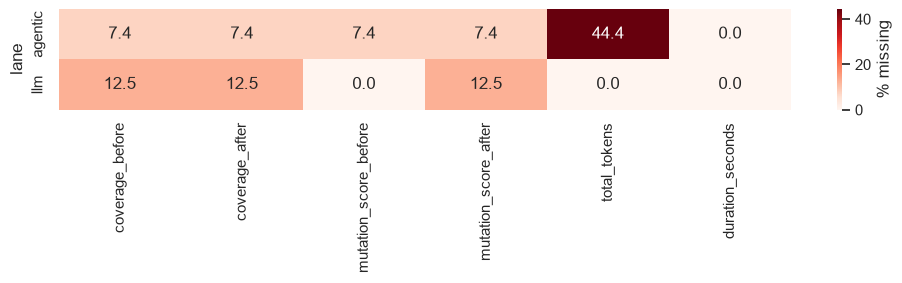

In [14]:
key_cols = [c for c in ['coverage_before', 'coverage_after', 'mutation_score_before',
                        'mutation_score_after', 'total_tokens', 'duration_seconds'] if c in A.columns]
null_pct = A.groupby('lane')[key_cols].apply(lambda g: g.isna().mean() * 100)
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(null_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% missing'})
plt.tight_layout()
plt.show()

## Failure cases

In [15]:
if failures.empty:
    print('No failure_cases.csv; run `python -m analysis export-failures`.')
else:
    display(failures.loc[failures['repo_name'] == REPO_NAME,
                         ['failure_case_id', 'lane', 'producer', 'attempt_number', 'chain_succeeded',
                          'preliminary_failure_label', 'failure_summary']])

,failure_case_id,lane,producer,attempt_number,chain_succeeded,preliminary_failure_label,failure_summary
4,5,llm,GLM-5.3-thinking-high,1,False,build_failed,Docker build validation failed before test exe...
13,14,agentic,mini-swe-agent-openai,1,False,no_change,NaN
18,19,agentic,mini-swe-agent-custom-gpt,1,False,no_change,NaN
